# 🏗️ Feature & Trade Pipeline

Generates `all_trades_with_features.h5` and `feature_columns.json` consumed by:
- `train_models_001.ipynb` — meta-labeling ML training
- `train_models_002.ipynb` — Lorentzian KNN risk management
- `t_loser_autopsy.ipynb`  — chronic loser analysis

**Outputs**
| File | Contents |
|------|----------|
| `all_trades_with_features.h5` | `training_df` — all closed trades with merged features |
| `feature_columns.json` | ordered list of model feature names |


# 1. Environment Setup

In [2]:
import sys
from pathlib import Path
backend_path = Path(__file__).parent.parent / "backend" if "__file__" in dir() else Path("../backend").resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

In [3]:
import importlib
import os
import json
import warnings
import numpy as np
import pandas as pd
import vectorbt as vbt
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

In [4]:
from deltalake import DeltaTable
from dotenv import load_dotenv
load_dotenv()

MINIO_ENDPOINT = "192.168.1.30:9000"
AWS_ACCESS_KEY_ID = "CzOwnLkEDXQy951AOqes"
AWS_SECRET_ACCESS_KEY = "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S"

storage_options = {
    "AWS_ACCESS_KEY_ID": AWS_ACCESS_KEY_ID,
    "AWS_SECRET_ACCESS_KEY": AWS_SECRET_ACCESS_KEY,
    "AWS_ENDPOINT_URL": f"http://{MINIO_ENDPOINT}",
    "AWS_ALLOW_HTTP": "true",
    "AWS_EC2_METADATA_DISABLED": "true",
    "AWS_REGION": 'us-east-1',
    "aws_conditional_put": "etag",
}

# 2. Load Price Data

In [5]:
## Load datasource from deltalake and save it to local h5 file
REMOTE_HOST = "http://192.168.1.30:9000"
# REMOTE_HOST = "https://minio.phuchuynh.xyz"

from deltalake import DeltaTable
def load_stock_data() -> pd.DataFrame:
    """Load stock data from delta lake, ensuring index uniqueness to avoid unstack ValueError"""
    try:
        from deltalake import DeltaTable
        storage_options = {
            "AWS_ACCESS_KEY_ID": "CzOwnLkEDXQy951AOqes",
            "AWS_SECRET_ACCESS_KEY": "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S",
            "AWS_ENDPOINT_URL": REMOTE_HOST,
            "AWS_ALLOW_HTTP": "true",
            "AWS_EC2_METADATA_DISABLED": "true",
            "AWS_REGION": 'us-east-1',
            "aws_conditional_put": "etag",
        }        
        dt = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)

        # Get data for last 2 years
        # Load watchlist symbols from CSV
        watchlist_path = "../backend/models/watchlist.csv"
        watchlist_df = pd.read_csv(watchlist_path)
        watchlist_symbols = watchlist_df.iloc[:, 0].values

        now = pd.Timestamp.now()
        start_date = now - pd.DateOffset(years=10)
        # Load all, then filter
        df = dt.to_pandas(
            filters=[("date", ">=", start_date), ("symbol", "in", watchlist_symbols)], 
            columns=["symbol", "date", "close", "open", "high", "low", "volume"]
        )
        
        # Remove duplicate (date, symbol) rows by keeping the last occurrence
        df = df.drop_duplicates(subset=["date", "symbol"], keep="last")
        # Convert to the same format as H5 store
        df = df.set_index(["date", "symbol"])
        stocks = df.unstack(level=1).bfill().ffill()
        
        print("Successfully loaded data from delta lake")
        return stocks
        
    except Exception as e:
        print(f"Error loading from delta lake: {e}")
        raise

import os
import pandas as pd

local_file = "stocks_data_latest.h5"
store_key = "stocks"

if os.path.exists(local_file):
    print(f"Loading stock data from local HDF5 file: {local_file}")
    with pd.HDFStore(local_file, mode="r") as store:
        df = store[store_key]
else:
    print("Local HDF5 file not found, loading stock data from Delta Lake...")
    df = load_stock_data()
    with pd.HDFStore(local_file, mode="w") as store:
        store.put(store_key, df)
    print(f"Stock data saved to {local_file}")

# Filter df to keep only columns for symbols in the watchlist (once)
watchlist_path = "../backend/models/watchlist.csv"
watchlist_df = pd.read_csv(watchlist_path)
watchlist_symbols = watchlist_df.iloc[:, 0].values
stocks = df.loc[:, df.columns.get_level_values('symbol').isin(watchlist_symbols)]
stocks


Loading stock data from local HDF5 file: stocks_data_latest.h5


close                                                               \
symbol       AAA    ABB    ACB    ACV   ADS    AGG    AGR    ANV    APH   ASM   
date                                                                            
2016-04-20  9.23   7.48   2.83  20.63  3.70  15.28   2.50   1.16  30.17  7.57   
2016-04-21  9.33   7.48   2.83  20.63  3.70  15.28   2.59   1.21  30.17  7.61   
2016-04-22  9.33   7.48   2.91  20.63  3.70  15.28   2.50   1.21  30.17  7.61   
2016-04-25  9.18   7.48   2.88  20.63  3.70  15.28   2.50   1.16  30.17  7.61   
2016-04-26  9.28   7.48   2.88  20.63  3.70  15.28   2.50   1.18  30.17  7.44   
...          ...    ...    ...    ...   ...    ...    ...    ...    ...   ...   
2026-04-13  7.01  14.60  23.75  46.30  8.64  13.00  14.95  24.35   5.56  5.86   
2026-04-14  7.10  14.60  24.00  46.40  9.07  12.90  15.05  24.90   5.58  5.94   
2026-04-15  7.12  14.50  23.80  46.70  9.11  12.95  14.95  24.45   5.62  5.89   
2026-04-16  7.04  14.60  23.65  46.30  9.12  12.80  14.90  24.75   5.57  5.80   
2026-04-17  7.03  14.60  23.75  45.90  9.09  12.90  14.85  25.00   5.58  5.77   

            ...       volume                                              \
symbol      ...      VNINDEX        VNM        VOS         VPB       VPG   
date        ...                                                            
2016-04-20  ...  108722464.0  1698460.0   154430.0  58299312.0    5000.0   
2016-04-21  ...  100005664.0   748780.0    82430.0  58299312.0    5000.0   
2016-04-22  ...  129717344.0   938560.0    94700.0  58299312.0    5000.0   
2016-04-25  ...  130331664.0   886480.0    58550.0  58299312.0    5000.0   
2016-04-26  ...  132638552.0   604360.0    87030.0  58299312.0    5000.0   
...         ...          ...        ...        ...         ...       ...   
2026-04-13  ...  767253440.0  3418300.0   876100.0  13557000.0  287600.0   
2026-04-14  ...  774260224.0  4247700.0   811900.0  14453500.0  316900.0   
2026-04-15  ...  804903616.0  4403200.0   935100.0  12229700.0  621100.0   
2026-04-16  ...  973731840.0  2272100.0  1491800.0  15412800.0  177000.0   
2026-04-17  ...  707285376.0  3115500.0  1314500.0  25668400.0  217700.0   

                                                                   
symbol            VPI         VRE        VSC       VTP        YEG  
date                                                               
2016-04-20     5000.0       800.0   156340.0     300.0     6100.0  
2016-04-21     5000.0       800.0    26330.0     300.0     6100.0  
2016-04-22     5000.0       800.0    67380.0     300.0     6100.0  
2016-04-25     5000.0       800.0    75940.0     300.0     6100.0  
2016-04-26     5000.0       800.0    36720.0     300.0     6100.0  
...               ...         ...        ...       ...        ...  
2026-04-13   738300.0   3915100.0  5244900.0  526500.0  2288200.0  
2026-04-14   833300.0   3851100.0  7001200.0  741600.0  1162000.0  
2026-04-15   633400.0  14406500.0  6993100.0  394500.0  1292300.0  
2026-04-16   635000.0  16443400.0  9699500.0  584900.0  1057800.0  
2026-04-17  5037500.0   7239000.0  4773900.0  258100.0   549200.0  

[2500 rows x 985 columns]

In [6]:
# Exclude VNINDEX from tradable universe (used as benchmark only)
symbols_in_columns = stocks.columns.get_level_values(1)
columns_to_keep_mask = symbols_in_columns != 'VNINDEX'
stocks_exclude_vnindex = stocks.loc[:, columns_to_keep_mask]

# 3. Compute Features from Raw OHLCV

Features are computed directly from `stocks_exclude_vnindex` using:
- `vbt.IndicatorFactory.from_talib` for standard TA (RSI, MFI, OBV, EMA, SMA, LINEARREG)
- Custom `_nb` Numba functions from `app.services.indicators` for YZ vol, z-score, AVWAP, relative strength
- Inline Numba Kalman filter for smoothed price (kf) and its z-scores

No Delta Lake / feature store dependency.

In [7]:
import numba as nb
from app.services.indicators import (
    avwap_func_nb,
    yang_zhang_volatility_nb,
    zscore_nb,
    relative_strength_nb,
    squeeze_ttm,
)

# ── Raw arrays ──────────────────────────────────────────────────────────────
close_df  = stocks_exclude_vnindex.close
open_df   = stocks_exclude_vnindex.open
high_df   = stocks_exclude_vnindex.high
low_df    = stocks_exclude_vnindex.low
volume_df = stocks_exclude_vnindex.volume

index   = close_df.index
symbols = close_df.columns

close_2d  = close_df.to_numpy().astype(np.float64)
open_2d   = open_df.to_numpy().astype(np.float64)
high_2d   = high_df.to_numpy().astype(np.float64)
low_2d    = low_df.to_numpy().astype(np.float64)
volume_2d = volume_df.to_numpy().astype(np.float64)

EPS = 1e-10

def _df(arr):
    """Wrap 2-D array into DataFrame with stock index/columns."""
    return pd.DataFrame(arr, index=index, columns=symbols)

def _safe_log_ratio_df(num_df, denom_df):
    """log1p((num - denom) / denom), NaN-safe."""
    safe = denom_df.where(denom_df != 0, np.nan)
    return np.log1p(((num_df - safe) / safe).clip(lower=-1 + EPS))

def _safe_log_ratio_2d(num, denom):
    safe = np.where(denom == 0, np.nan, denom)
    ratio = (num - safe) / safe
    return np.log1p(np.clip(ratio, -1 + EPS, None))


# ── 1. RSI (5, 14) ──────────────────────────────────────────────────────────
RSI = vbt.IndicatorFactory.from_talib('RSI')
rsi_5_df  = RSI.run(close_df, timeperiod=5).real
rsi_14_df = RSI.run(close_df, timeperiod=14).real

# ── 2. MFI (21) ─────────────────────────────────────────────────────────────
mfi_21_df = vbt.IndicatorFactory.from_talib('MFI').run(
    high_df, low_df, close_df, volume_df, timeperiod=21).real

# ── 3. OBV ──────────────────────────────────────────────────────────────────
obv_df = vbt.IndicatorFactory.from_talib('OBV').run(close_df, volume_df).real

# ── 4. Log return ────────────────────────────────────────────────────────────
log_return_df = np.log(close_df / close_df.shift(1))

# ── 5. EMA distances (10, 20, 50, 200) ──────────────────────────────────────
EMA = vbt.IndicatorFactory.from_talib('EMA')
ema_10_df  = EMA.run(close_df, timeperiod=10).real
ema_20_df  = EMA.run(close_df, timeperiod=20).real
ema_50_df  = EMA.run(close_df, timeperiod=50).real
ema_200_df = EMA.run(close_df, timeperiod=200).real

ema_10_dist  = _safe_log_ratio_df(close_df, ema_10_df)
ema_20_dist  = _safe_log_ratio_df(close_df, ema_20_df)
ema_50_dist  = _safe_log_ratio_df(close_df, ema_50_df)
ema_200_dist = _safe_log_ratio_df(close_df, ema_200_df)

# ── 6. Volume MA ratio (10, 20) ──────────────────────────────────────────────
SMA = vbt.IndicatorFactory.from_talib('SMA')
vol_ma_10_dist = _safe_log_ratio_df(volume_df, SMA.run(volume_df, timeperiod=10).real)
vol_ma_20_dist = _safe_log_ratio_df(volume_df, SMA.run(volume_df, timeperiod=20).real)

# ── 7. EFI z-score (Elder Force Index = close.diff * volume) ────────────────
efi_2d = np.nan_to_num((close_df.diff() * volume_df).to_numpy().astype(np.float64))
efi_zscore_10_2d = zscore_nb(efi_2d, window=10)
efi_zscore_20_2d = zscore_nb(efi_2d, window=20)

# ── 8. AVWAP distances (anchored to rolling highest / lowest) ────────────────
avwap_hi_2d = avwap_func_nb(close_2d, high_2d, low_2d, volume_2d, is_highest=True,  window=200)
avwap_lo_2d = avwap_func_nb(close_2d, high_2d, low_2d, volume_2d, is_highest=False, window=200)
vwap_dist_hi_2d = _safe_log_ratio_2d(close_2d, avwap_hi_2d)
vwap_dist_lo_2d = _safe_log_ratio_2d(close_2d, avwap_lo_2d)

# ── 9. Relative strength vs VNINDEX (10, 20) ─────────────────────────────────
vnindex_2d = np.tile(
    stocks.close['VNINDEX'].values.reshape(-1, 1).astype(np.float64),
    (1, close_2d.shape[1]),
)
rs_10_2d, mrs_10_2d = relative_strength_nb(close_2d, vnindex_2d, window=10)
rs_20_2d, mrs_20_2d = relative_strength_nb(close_2d, vnindex_2d, window=20)

# ── 10. Cross-sectional MSR rank ─────────────────────────────────────────────
msr_rank_10_2d = _df(mrs_10_2d).rank(axis=1, pct=True).to_numpy()
msr_rank_20_2d = _df(mrs_20_2d).rank(axis=1, pct=True).to_numpy()

# ── 11. Z-score of log return (10, 20) ───────────────────────────────────────
lr_2d = np.nan_to_num(log_return_df.to_numpy().astype(np.float64))
zscore_lr_10_2d = zscore_nb(lr_2d, window=10)
zscore_lr_20_2d = zscore_nb(lr_2d, window=20)

# ── 12. Yang-Zhang volatility (10, 20) ───────────────────────────────────────
# signature: yang_zhang_volatility_nb(close, open, high, low, window, periods)
yz_vol_10_2d = yang_zhang_volatility_nb(close_2d, open_2d, high_2d, low_2d, window=10, periods=252).astype(np.float64)
yz_vol_20_2d = yang_zhang_volatility_nb(close_2d, open_2d, high_2d, low_2d, window=20, periods=252).astype(np.float64)

# ── 13. DC TMV — TTM Squeeze momentum value ──────────────────────────────────
# squeeze_ttm uses vbt.IndicatorFactory.from_talib internally → handles 2-D DataFrames
_diff, dc_tmv_raw = squeeze_ttm(
    close_df.to_numpy(), high_df.to_numpy(), low_df.to_numpy(),
    bb_period=10, bb_mult=1.2, bb_matype=3,
    kc_period=10, kc_mult=1.2,
    donichan_period=10, osc_smoothing_period=10,
)
# squeeze_ttm receives ndarray → vbt wraps columns per param combo → result may be 3-D
# If 2-D pass-through, take as-is; if 1 param-combo dim, squeeze it out
if hasattr(dc_tmv_raw, 'to_numpy'):
    dc_tmv_2d = dc_tmv_raw.to_numpy()
else:
    dc_tmv_2d = np.asarray(dc_tmv_raw)
if dc_tmv_2d.ndim == 3:
    dc_tmv_2d = dc_tmv_2d[:, :, 0]  # drop single param-combo axis

# ── 14. Kalman-filter smoothed price → distance + z-scores ───────────────────
@nb.njit(parallel=True)
def _kalman_2d(prices, obs_cov=1.0, trans_cov=0.01):
    """Scalar Kalman filter applied independently to each column."""
    T, S = prices.shape
    out = np.empty_like(prices)
    for j in nb.prange(S):
        x = prices[0, j]
        p = 1.0
        for i in range(T):
            p_pred = p + trans_cov
            gain   = p_pred / (p_pred + obs_cov)
            x      = x + gain * (prices[i, j] - x)
            p      = (1.0 - gain) * p_pred
            out[i, j] = x
    return out

kf_2d          = _kalman_2d(close_2d)
kf_dist_2d     = _safe_log_ratio_2d(close_2d, kf_2d)
zscore_kf_10_2d = zscore_nb(kf_2d, window=10)
zscore_kf_20_2d = zscore_nb(kf_2d, window=20)


# ── Assemble features_df (date × symbol long form) ──────────────────────────
_feat_arrays = {
    'rsi_window_5':           rsi_5_df.to_numpy(),
    'rsi_window_14':          rsi_14_df.to_numpy(),
    'mfi_21':                 mfi_21_df.to_numpy(),
    'obv':                    obv_df.to_numpy(),
    'log_return':             log_return_df.to_numpy(),
    'volume_threshold_ma_10': vol_ma_10_dist.to_numpy(),
    'volume_threshold_ma_20': vol_ma_20_dist.to_numpy(),
    'ema_10_distance':        ema_10_dist.to_numpy(),
    'ema_20_distance':        ema_20_dist.to_numpy(),
    'ema_50_distance':        ema_50_dist.to_numpy(),
    'ema_200_distance':       ema_200_dist.to_numpy(),
    'vwap_distance_highest':  vwap_dist_hi_2d,
    'vwap_distance_lowest':   vwap_dist_lo_2d,
    'efi_zscore_10':          efi_zscore_10_2d,
    'efi_zscore_20':          efi_zscore_20_2d,
    'rs_10':                  rs_10_2d,
    'rs_20':                  rs_20_2d,
    'mrs_10':                 mrs_10_2d,
    'mrs_20':                 mrs_20_2d,
    'msr_rank_10':            msr_rank_10_2d,
    'msr_rank_20':            msr_rank_20_2d,
    'zscore_10_log_return':   zscore_lr_10_2d,
    'zscore_20_log_return':   zscore_lr_20_2d,
    'yz_vol_10':              yz_vol_10_2d,
    'yz_vol_20':              yz_vol_20_2d,
    'dc_tmv':                 dc_tmv_2d,
    'kf_distance':            kf_dist_2d,
    'zscore_kf_10':           zscore_kf_10_2d,
    'zscore_kf_20':           zscore_kf_20_2d,
    # keep close for downstream kf_distance sanity checks (excluded from SAFE_FEATURE_COLS)
    'close':                  close_2d,
}

features_df = pd.concat(
    [_df(arr).stack().rename(feat) for feat, arr in _feat_arrays.items()],
    axis=1,
)
features_df.index.names = ['date', 'symbol']

print(f"Features computed: {features_df.shape[1]} columns × {len(features_df):,} rows")
print(f"Date range: {features_df.index.get_level_values('date').min()} "
      f"→ {features_df.index.get_level_values('date').max()}")
print(list(features_df.columns))


Features computed: 30 columns × 490,000 rows
Date range: 2016-04-20 00:00:00 → 2026-04-17 00:00:00
['rsi_window_5', 'rsi_window_14', 'mfi_21', 'obv', 'log_return', 'volume_threshold_ma_10', 'volume_threshold_ma_20', 'ema_10_distance', 'ema_20_distance', 'ema_50_distance', 'ema_200_distance', 'vwap_distance_highest', 'vwap_distance_lowest', 'efi_zscore_10', 'efi_zscore_20', 'rs_10', 'rs_20', 'mrs_10', 'mrs_20', 'msr_rank_10', 'msr_rank_20', 'zscore_10_log_return', 'zscore_20_log_return', 'yz_vol_10', 'yz_vol_20', 'dc_tmv', 'kf_distance', 'zscore_kf_10', 'zscore_kf_20', 'close']


In [8]:
# ── Autopsy-Driven Feature Additions ────────────────────────────────────────
# Source: loser_autopsy_20260501_1302.json
#
# Catastrophic loss drivers (Cohen's d in parentheses):
#   yz_vol_10/20 (0.74) → vol z-score & acceleration
#   mrs_10 (0.49), msr_rank_10 (0.39) → overextension ratio
#   ema_10_distance (0.28) → near/far EMA ratio
#   vwap_distance_highest (0.27) → already in model
#   log_return on entry day (0.24) → breakout-day return
# General discriminators (all |d|<0.2 but statistically significant):
#   msr_rank_10, mrs_10/20, kf_distance, ema_20/50_distance
# Market regime: 8.1% win-rate gap bull vs bear; vol regime spans 28.5–50.0%

# 15. YZ vol z-score — how elevated vs its own 63-day history?
#     Direct catastrophic predictor (d~0.74)
yz_vol_zscore_10_2d = zscore_nb(yz_vol_10_2d, window=63)
yz_vol_zscore_20_2d = zscore_nb(yz_vol_20_2d, window=63)

# 16. Vol acceleration: yz_vol_10 / yz_vol_20
#     Rising ratio = volatility regime accelerating → higher crash risk
yz_vol_accel_2d = np.where(yz_vol_20_2d > 1e-9,
                            yz_vol_10_2d / (yz_vol_20_2d + 1e-9), np.nan)

# 17. MRS overextension ratio: mrs_10 / |mrs_20|
#     Catastrophic losers: mrs_10=3.9 vs mrs_20=1.8 — momentum bubble at entry
mrs_overext_ratio_2d = np.where(np.abs(mrs_20_2d) > 1e-9,
                                 mrs_10_2d / (np.abs(mrs_20_2d) + 1e-9), np.nan)

# 18. EMA near/far extension ratio: ema_10_dist / ema_50_dist
#     High ratio → price extended short-term but not long-term → false breakout
_ema10_arr = ema_10_dist.to_numpy()
_ema50_arr = ema_50_dist.to_numpy()
ema_near_far_ratio_2d = np.where(np.abs(_ema50_arr) > 1e-9,
                                  _ema10_arr / (np.abs(_ema50_arr) + 1e-9), np.nan)

# 19. RSI cross-sectional rank: are we entering the most overbought stock today?
rsi_rank_14_2d = _df(rsi_14_df.to_numpy()).rank(axis=1, pct=True).to_numpy()

# 20. Volume spike vs 5-day average — breakout quality confirmation
_vol_sma5 = SMA.run(volume_df, timeperiod=5).real.to_numpy()
vol_spike_2d = _safe_log_ratio_2d(volume_2d, _vol_sma5)

# 21. Close position in day's high-low range
#     0 = closed at low, 1 = closed at high; weak close on breakout day is bearish
_day_range = high_2d - low_2d
close_position_2d = np.where(_day_range > 1e-9, (close_2d - low_2d) / _day_range, 0.5)

# 22. Distance from 20d / 60d rolling HIGH close (false breakout indicator)
#     log1p((close - rolling_high) / rolling_high) ≤ 0
#     ≈ 0 → fresh breakout to new high; very negative → chasing extended move
dist_20d_high_2d = _safe_log_ratio_2d(close_2d, close_df.rolling(20).max().to_numpy())
dist_60d_high_2d = _safe_log_ratio_2d(close_2d, close_df.rolling(60).max().to_numpy())

# ── VNINDEX Market Regime Features ──────────────────────────────────────────
# Autopsy: Bull=35.7% vs Bear=43.8% win rate (+8.1%); vol regime spans 28.5–50.0%
_vn_px = stocks['close']['VNINDEX'].dropna().sort_index()
_vn_px = _vn_px.reindex(close_df.index, method='ffill')

_vn_ema50  = _vn_px.ewm(span=50,  adjust=False).mean()
_vn_ema200 = _vn_px.ewm(span=200, adjust=False).mean()
_vn_vol20  = _vn_px.pct_change().rolling(20).std()

_vn_df = pd.DataFrame({
    'vnindex_above_ema50':  (_vn_px > _vn_ema50).astype(float),
    'vnindex_above_ema200': (_vn_px > _vn_ema200).astype(float),
    'vnindex_ret_5d':       _vn_px.pct_change(5),
    'vnindex_ret_20d':      _vn_px.pct_change(20),
    'vnindex_vol_20d':      _vn_vol20,
    'vnindex_vol_zscore':   ((_vn_vol20 - _vn_vol20.rolling(252).mean())
                             / (_vn_vol20.rolling(252).std() + 1e-9)),
    'vnindex_drawdown':     _vn_px / _vn_px.rolling(252).max() - 1,
}, index=_vn_px.index)

# ── Assemble and append to features_df ─────────────────────────────────────
_extra_feat_arrays = {
    'yz_vol_zscore_10':   yz_vol_zscore_10_2d,
    'yz_vol_zscore_20':   yz_vol_zscore_20_2d,
    'yz_vol_accel':       yz_vol_accel_2d,
    'mrs_overext_ratio':  mrs_overext_ratio_2d,
    'ema_near_far_ratio': ema_near_far_ratio_2d,
    'rsi_rank_14':        rsi_rank_14_2d,
    'vol_spike':          vol_spike_2d,
    'close_position':     close_position_2d,
    'dist_20d_high':      dist_20d_high_2d,
    'dist_60d_high':      dist_60d_high_2d,
}
_extra_features = pd.concat(
    [_df(arr).stack().rename(feat) for feat, arr in _extra_feat_arrays.items()],
    axis=1,
)
_extra_features.index.names = ['date', 'symbol']

# Broadcast VNINDEX (date-level) to all (date, symbol) rows
_vn_long = _vn_df.reindex(features_df.index.get_level_values('date'))
_vn_long.index = features_df.index

features_df = pd.concat([features_df, _extra_features, _vn_long], axis=1)

# Fill NaN in ratio/zscore features with neutral values to avoid dropna() data loss
_ratio_fills = {
    'yz_vol_accel':       1.0,   # no acceleration = ratio of 1
    'mrs_overext_ratio':  1.0,   # no overextension
    'ema_near_far_ratio': 1.0,   # no near/far divergence
    'yz_vol_zscore_10':   0.0,   # neutral z-score
    'yz_vol_zscore_20':   0.0,
}
for col, fill in _ratio_fills.items():
    if col in features_df.columns:
        features_df[col] = features_df[col].fillna(fill)

print(f"Total features: {features_df.shape[1]} "
      f"(+{len(_extra_feat_arrays)} technical, +7 VNINDEX regime)")

Total features: 47 (+10 technical, +7 VNINDEX regime)


In [9]:
# ── VN Priority Features ─────────────────────────────────────────────────────
# Volatility: rv_20, vol_pctile, atr_pct
# Position:   range_pos_60, dist_from_high_60
# Trend:      trend_20, sma_alignment
# Volume:     vol_zscore, dollar_vol_pctile
# Cross-sect: rs_vnindex, corr_vnindex, beta_60d

# 1. Realized volatility 20d (annualised std of log returns)
rv_20_2d = (log_return_df.rolling(20).std() * np.sqrt(252)).to_numpy()

# 2. Volatility percentile — fraction of past 252d where yz_vol_10 was lower
_yz10 = yz_vol_10_2d
vol_pctile_2d = np.full_like(_yz10, np.nan)
_W_vol = 252
for _t in range(_W_vol, _yz10.shape[0]):
    vol_pctile_2d[_t] = (_yz10[_t - _W_vol:_t] < _yz10[_t]).mean(axis=0)

# 3. ATR % — ATR(14) / close  (bounded ~0–0.10 for most VN stocks)
ATR = vbt.IndicatorFactory.from_talib('ATR')
atr_pct_2d = (ATR.run(high_df, low_df, close_df, timeperiod=14).real
              / close_df.replace(0, np.nan)).to_numpy()

# 4. Range position in 60d HIGH–LOW band  (0=at 60d low, 1=at 60d high)
_h60 = high_df.rolling(60).max().to_numpy()
_l60 = low_df.rolling(60).min().to_numpy()
_r60 = _h60 - _l60
range_pos_60_2d = np.where(_r60 > 1e-9, (close_2d - _l60) / _r60, 0.5)

# 5. Distance from 60d intraday HIGH (log ratio, always ≤ 0)
dist_from_high_60_2d = _safe_log_ratio_2d(close_2d, _h60)

# 6. Trend 20d — log return over 20 bars
trend_20_2d = np.log(close_df / close_df.shift(20)).to_numpy()

# 7. SMA alignment — fraction of [SMA10,20,50,200] that price is above (0–1)
_sma10  = SMA.run(close_df, timeperiod=10).real.to_numpy()
_sma20  = SMA.run(close_df, timeperiod=20).real.to_numpy()
_sma50  = SMA.run(close_df, timeperiod=50).real.to_numpy()
_sma200 = SMA.run(close_df, timeperiod=200).real.to_numpy()
sma_alignment_2d = (
    (close_2d > _sma10).astype(float) + (close_2d > _sma20).astype(float) +
    (close_2d > _sma50).astype(float) + (close_2d > _sma200).astype(float)
) / 4.0

# 8. Volume z-score — (vol - vol_ma20) / vol_std20
_vol_std20 = volume_df.rolling(20).std().to_numpy()
vol_zscore_2d = np.where(
    _vol_std20 > 1e-9,
    (volume_2d - volume_df.rolling(20).mean().to_numpy()) / _vol_std20,
    0.0,
)

# 9. Dollar-volume percentile — cross-sectional rank of 20d avg (close × volume)
dollar_vol_pctile_2d = (
    (close_df * volume_df).rolling(20).mean()
    .rank(axis=1, pct=True)
    .to_numpy()
)

# 10–12. RS / Corr / Beta vs VNINDEX (60d rolling)
_vn_r1 = _vn_px.pct_change().reindex(close_df.index, method='ffill').values
_stk_r1 = close_df.pct_change().to_numpy()
_stk_r20 = close_df.pct_change(20).to_numpy()
_vn_r20  = _vn_px.pct_change(20).reindex(close_df.index, method='ffill').values

rs_vnindex_2d    = _stk_r20 - _vn_r20.reshape(-1, 1)
corr_vnindex_2d  = np.full_like(close_2d, np.nan)
beta_60d_2d      = np.full_like(close_2d, np.nan)

_Wc = 60
for _t in range(_Wc, close_2d.shape[0]):
    _vn_w  = _vn_r1[_t - _Wc:_t]
    _stk_w = _stk_r1[_t - _Wc:_t, :]
    _vn_m  = _vn_w.mean()
    _stk_m = _stk_w.mean(axis=0)
    _vn_d  = _vn_w - _vn_m
    _cov   = (_vn_d.reshape(-1, 1) * (_stk_w - _stk_m)).mean(axis=0)
    _var   = float((_vn_d ** 2).mean()) + 1e-9
    corr_vnindex_2d[_t] = _cov / (np.sqrt(_var) * (_stk_w.std(axis=0) + 1e-9))
    beta_60d_2d[_t]     = _cov / _var

# ── Append to features_df ────────────────────────────────────────────────────
_vn_priority_arrays = {
    'rv_20':             rv_20_2d,
    'vol_pctile':        vol_pctile_2d,
    'atr_pct':           atr_pct_2d,
    'range_pos_60':      range_pos_60_2d,
    'dist_from_high_60': dist_from_high_60_2d,
    'trend_20':          trend_20_2d,
    'sma_alignment':     sma_alignment_2d,
    'vol_zscore':        vol_zscore_2d,
    'dollar_vol_pctile': dollar_vol_pctile_2d,
    'rs_vnindex':        rs_vnindex_2d,
    'corr_vnindex':      corr_vnindex_2d,
    'beta_60d':          beta_60d_2d,
}
_vn_prio_df = pd.concat(
    [_df(arr).stack().rename(feat) for feat, arr in _vn_priority_arrays.items()],
    axis=1,
)
_vn_prio_df.index.names = ['date', 'symbol']
features_df = pd.concat([features_df, _vn_prio_df], axis=1)

# Fill NaN neutral values
_fills = {'range_pos_60': 0.5, 'sma_alignment': 0.5,
           'vol_zscore': 0.0, 'corr_vnindex': 0.0, 'beta_60d': 1.0}
for _c, _v in _fills.items():
    features_df[_c] = features_df[_c].fillna(_v)

print(f'VN priority features added: {len(_vn_priority_arrays)}')
print(f'Total features: {features_df.shape[1]}')


VN priority features added: 12
Total features: 59


# 4. Generate Trade Signals (Primary Model)

This is your existing breakout strategy — the **primary model** in the meta-labeling framework. It decides *which trades to take*. The meta-model below will decide *whether each trade is worth taking*.


In [10]:
from app.services.strategies import BreakoutTTMVersion2

# Best params from backtest_service.py
# V1: Trial #453 — Total Return 403%, Sortino 0.995
# V2: Trial #493 — Total Return 397%, Sortino 1.001
PARAM_NAMES = [
    'bb_window', 'bb_multiplier', 'kc_window', 'kc_multiplier',
    'atr_window', 'momentum_window', 'donichan_window', 'entry_version',
    'kc_atr_period', 'osc_smoothing_period', 'matype',
    'william_vix_period', 'consecutive_neg_threshold',
]

strategy_params = [
    (14, 1.0, 51, 1.2, 11, 12,  9, 'v1', 7, 11, 0, 22, 14),  # V1
    (18, 1.2, 53, 1.5,  5, 12,  9, 'v2', 5, 11, 0, 27, 13),  # V2
]

total_trades = pd.DataFrame()
total_open_trades = pd.DataFrame()

for params in strategy_params:
    param_dict = dict(zip(PARAM_NAMES, params))
    # move entry_version to front (cosmetic, matches backtest_service convention)
    entry_version = param_dict.pop('entry_version')
    param_dict = {'entry_version': entry_version, **param_dict}

    breakout_strategy = BreakoutTTMVersion2(stocks_exclude_vnindex, **param_dict)
    portfolio = breakout_strategy.get_portfolio()
    print(f"Params: {param_dict}")
    # sharpe_ratio() returns a Series (one per symbol-group) — take mean
    sharpe_val = float(portfolio.sharpe_ratio().mean())
    trade_count = int(portfolio.trades.count().sum())
    print(f"Sharpe (mean across groups): {sharpe_val:.3f}, Trades: {trade_count}")

    trades = pd.DataFrame(portfolio.trades.records)
    trades['metadata'] = json.dumps(param_dict)
    open_trade = pd.DataFrame(portfolio.trades.open.records)
    open_trade['metadata'] = json.dumps(param_dict)

    total_trades = pd.concat([total_trades, trades])
    total_open_trades = pd.concat([total_open_trades, open_trade])

total_trades['type'] = 'closed_trades'
total_open_trades['type'] = 'open_trades'

# Filter: keep closed trades that are not also in open trades
open_trade_keys = pd.MultiIndex.from_frame(total_open_trades[['col', 'entry_idx']])
total_trade_keys = pd.MultiIndex.from_frame(total_trades[['col', 'entry_idx']])
mask = ~total_trade_keys.isin(open_trade_keys)
filtered_total_trades = total_trades[mask]

# Combine closed + open
all_trades_df = pd.concat([filtered_total_trades, total_open_trades])
all_trades_df = (
    all_trades_df
    .drop_duplicates(subset=['col', 'entry_idx'], keep='first')
    .reset_index(drop=True)
)
# col maps to stocks_exclude_vnindex (not stocks — VNINDEX was removed)
all_trades_df['symbol'] = all_trades_df.apply(
    lambda x: stocks_exclude_vnindex.close.columns[x['col']], axis=1)
all_trades_df['entry_date'] = all_trades_df.apply(
    lambda x: stocks_exclude_vnindex.index[x['entry_idx']], axis=1)
all_trades_df['exit_date'] = all_trades_df.apply(
    lambda x: stocks_exclude_vnindex.index[min(int(x['exit_idx']), len(stocks_exclude_vnindex) - 1)]
              if pd.notna(x['exit_idx']) else stocks_exclude_vnindex.index[-1],
    axis=1,
)
all_trades_df['date'] = all_trades_df['entry_date']  # alias for merging
print(f"\nTotal trades generated: {len(all_trades_df)}")
print(f"Closed: {(all_trades_df['type']=='closed_trades').sum()}, "
      f"Open: {(all_trades_df['type']=='open_trades').sum()}")


Params: {'entry_version': 'v1', 'bb_window': 14, 'bb_multiplier': 1.0, 'kc_window': 51, 'kc_multiplier': 1.2, 'atr_window': 11, 'momentum_window': 12, 'donichan_window': 9, 'kc_atr_period': 7, 'osc_smoothing_period': 11, 'matype': 0, 'william_vix_period': 22, 'consecutive_neg_threshold': 14}
Sharpe (mean across groups): 0.697, Trades: 11746
Params: {'entry_version': 'v2', 'bb_window': 18, 'bb_multiplier': 1.2, 'kc_window': 53, 'kc_multiplier': 1.5, 'atr_window': 5, 'momentum_window': 12, 'donichan_window': 9, 'kc_atr_period': 5, 'osc_smoothing_period': 11, 'matype': 0, 'william_vix_period': 27, 'consecutive_neg_threshold': 13}
Sharpe (mean across groups): 0.679, Trades: 12195

Total trades generated: 15435
Closed: 15228, Open: 207


In [11]:
all_trades_df.sort_values(by='entry_date', ascending=False, inplace=True)
all_trades_df

,id,col,size,entry_idx,entry_price,entry_fees,exit_idx,exit_price,exit_fees,pnl,return,direction,status,parent_id,metadata,type,symbol,entry_date,exit_date,date
15406,3337,54,2.668114,2499,84.50,0.0,2499,84.50,0.0,0.000000,0.000000,0,0,3337,"{""entry_version"": ""v2"", ""bb_window"": 18, ""bb_m...",open_trades,FOX,2026-04-17,2026-04-17,2026-04-17
15346,8240,138,0.757082,2499,15.40,0.0,2499,15.40,0.0,0.000000,0.000000,0,0,8240,"{""entry_version"": ""v1"", ""bb_window"": 14, ""bb_m...",open_trades,PVP,2026-04-17,2026-04-17,2026-04-17
15419,7174,115,5.265545,2499,26.00,0.0,2499,26.00,0.0,0.000000,0.000000,0,0,7174,"{""entry_version"": ""v2"", ""bb_window"": 18, ""bb_m...",open_trades,NT2,2026-04-17,2026-04-17,2026-04-17
15428,10241,164,30.771414,2499,22.90,0.0,2499,22.90,0.0,0.000000,0.000000,0,0,10241,"{""entry_version"": ""v2"", ""bb_window"": 18, ""bb_m...",open_trades,TNG,2026-04-17,2026-04-17,2026-04-17
15280,3759,63,4.025908,2498,73.60,0.0,2499,74.60,0.0,4.025908,0.013587,0,0,3759,"{""entry_version"": ""v1"", ""bb_window"": 14, ""bb_m...",open_trades,GMD,2026-04-16,2026-04-17,2026-04-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10292,10438,175,12.224939,19,8.18,0.0,43,9.26,0.0,13.202934,0.132029,0,1,10438,"{""entry_version"": ""v1"", ""bb_window"": 14, ""bb_m...",closed_trades,VGC,2016-05-19,2016-06-22,2016-05-19
11343,11504,192,3.110420,19,32.15,0.0,397,35.28,0.0,9.735614,0.097356,0,1,11504,"{""entry_version"": ""v1"", ""bb_window"": 14, ""bb_m...",closed_trades,VRE,2016-05-19,2017-11-15,2016-05-19
8051,8169,138,12.853470,19,7.78,0.0,176,9.49,0.0,21.979434,0.219794,0,1,8169,"{""entry_version"": ""v1"", ""bb_window"": 14, ""bb_m...",closed_trades,PVP,2016-05-19,2016-12-27,2016-05-19
5723,5806,98,45.045045,19,2.22,0.0,39,2.26,0.0,1.801802,0.018018,0,1,5806,"{""entry_version"": ""v1"", ""bb_window"": 14, ""bb_m...",closed_trades,LCG,2016-05-19,2016-06-16,2016-05-19


# 5. Define Labels (with Transaction Costs & Threshold)

## ⚠️ Improvement over Original

Original used: `Y = return > 0` — too lenient, includes marginal trades.

New definition includes:
- **Transaction costs** (round-trip ~0.3% in VN market)
- **Minimum return threshold** to filter marginally profitable trades
- This forces the model to identify *clearly* profitable setups


Total closed trades: 15435
Label distribution:
Y
Loss/Marginal    0.611856
Clear Win        0.388144
Name: proportion, dtype: float64

Mean net return (winners):  16.132%
Mean net return (losers):    -5.480%


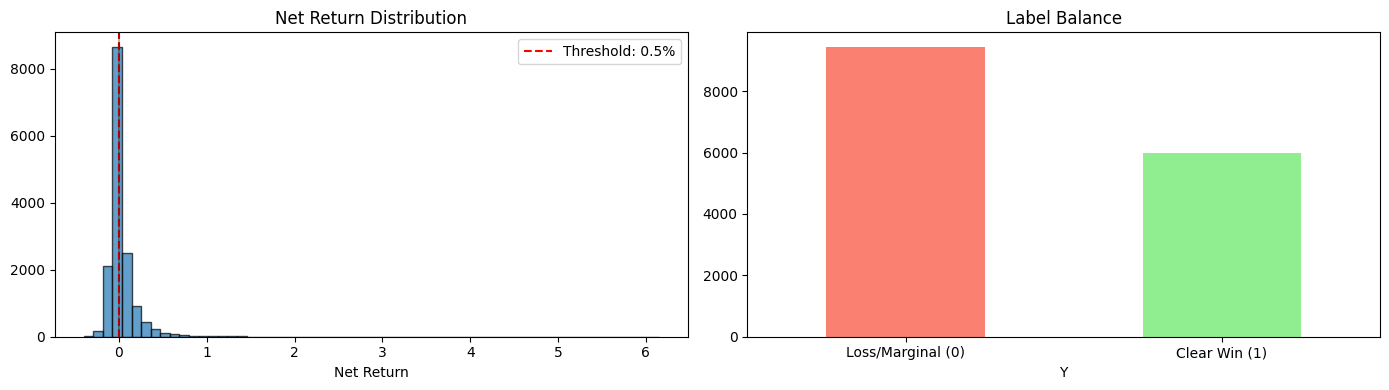

In [ ]:
# === Label Configuration ===
ROUND_TRIP_COST   = 0.003   # 30 bps round-trip (entry + exit fees)
MIN_RETURN_EDGE   = 0.005   # require at least 50 bps net edge
LABEL_THRESHOLD   = ROUND_TRIP_COST + MIN_RETURN_EDGE  # ~0.8%

# Filter out open trades (no realized return) for training
closed_trades = all_trades_df[all_trades_df['type'] == 'closed_trades'].copy()

# Net return after costs
closed_trades['net_return'] = closed_trades['return'] - ROUND_TRIP_COST

# Binary label: 1 if net return > threshold, else 0
closed_trades['Y'] = (closed_trades['net_return'] > MIN_RETURN_EDGE).astype(int)

# Sort by entry_date — CRITICAL for time-series ordering
closed_trades = closed_trades.sort_values('entry_date').reset_index(drop=True)

print(f"Total closed trades: {len(closed_trades)}")
print(f"Label distribution:")
print(closed_trades['Y'].value_counts(normalize=True).rename({0: 'Loss/Marginal', 1: 'Clear Win'}))
print(f"\nMean net return (winners):  {closed_trades.loc[closed_trades.Y==1, 'net_return'].mean():.3%}")
print(f"Mean net return (losers):    {closed_trades.loc[closed_trades.Y==0, 'net_return'].mean():.3%}")

# Plot return distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(closed_trades['net_return'], bins=60, edgecolor='black', alpha=0.7)
ax[0].axvline(MIN_RETURN_EDGE, color='red', linestyle='--', label=f'Threshold: {MIN_RETURN_EDGE:.1%}')
ax[0].axvline(0, color='black', linestyle='-', alpha=0.3)
ax[0].set_title('Net Return Distribution')
ax[0].set_xlabel('Net Return')
ax[0].legend()

closed_trades['Y'].value_counts().plot(kind='bar', ax=ax[1], color=['salmon', 'lightgreen'])
ax[1].set_title('Label Balance')
ax[1].set_xticklabels(['Loss/Marginal (0)', 'Clear Win (1)'], rotation=0)
plt.tight_layout()
plt.show()

# 6. Merge Features at Entry Time

We merge features computed **at entry date** for each trade. Since features in `features_df` are already point-in-time (rolling windows on past data), merging on `(date, symbol)` is safe **as long as we exclude any `next_*` columns**.


In [13]:
features_df_reset = features_df.reset_index()

# 🚨 Exclude any look-ahead columns by name pattern
SAFE_FEATURE_COLS = [
    c for c in features_df_reset.columns
    if not c.startswith('next_') and c not in ['open', 'high', 'low', 'close', 'volume']
]

print(f"Safe (no look-ahead) features: {len(SAFE_FEATURE_COLS) - 2}")  # -2 for date, symbol

# Merge
training_df = pd.merge(
    closed_trades[['symbol', 'date', 'entry_date', 'exit_date',
                   'return', 'net_return', 'Y']],
    features_df_reset[SAFE_FEATURE_COLS],
    left_on=['date', 'symbol'],
    right_on=['date', 'symbol'],
    how='inner',
)

# Sort by entry date AGAIN (post-merge)
training_df = training_df.sort_values('entry_date').reset_index(drop=True)
training_df = training_df.dropna()

print(f"\nFinal training rows: {len(training_df)}")
print(f"Date range: {training_df['entry_date'].min()} → {training_df['entry_date'].max()}")

Safe (no look-ahead) features: 58

Final training rows: 14128
Date range: 2017-05-22 00:00:00 → 2026-04-17 00:00:00


In [14]:
# ── Temporal & Rolling Features (post-merge, look-ahead-safe) ───────────────
training_df = training_df.sort_values('entry_date').reset_index(drop=True)

# Seasonality — significant by χ² test in autopsy
training_df['dow_sin']        = np.sin(2 * np.pi * training_df['entry_date'].dt.dayofweek / 5)
training_df['dow_cos']        = np.cos(2 * np.pi * training_df['entry_date'].dt.dayofweek / 5)
training_df['month_sin']      = np.sin(2 * np.pi * training_df['entry_date'].dt.month / 12)
training_df['month_cos']      = np.cos(2 * np.pi * training_df['entry_date'].dt.month / 12)
training_df['is_quarter_end'] = (
    (training_df['entry_date'].dt.month % 3 == 0) &
    (training_df['entry_date'].dt.day > 20)
).astype(int)

print(f"Temporal features added: dow_sin, dow_cos, month_sin, month_cos, is_quarter_end")
print(f"training_df shape: {training_df.shape}")

Temporal features added: dow_sin, dow_cos, month_sin, month_cos, is_quarter_end
training_df shape: (14128, 70)


In [15]:
# ── Feature Quality Diagnostics ─────────────────────────────────────────────
# Shows NaN / Inf counts for every numeric feature after the full merge.
# Run this before training; any column with NaN% > 0 needs a fill strategy.

_feat_cols = [c for c in training_df.columns
              if c not in {'symbol', 'date', 'entry_date', 'exit_date',
                           'return', 'net_return', 'Y', 'metadata', 'type'}
              and pd.api.types.is_numeric_dtype(training_df[c])]

_n = len(training_df)
_rows = []
for col in _feat_cols:
    s = training_df[col]
    nan_n  = s.isna().sum()
    inf_n  = np.isinf(s.replace([np.nan], 0)).sum()
    finite = s.replace([np.inf, -np.inf], np.nan).dropna()
    _rows.append({
        'feature':   col,
        'nan_count': int(nan_n),
        'nan_pct':   round(nan_n / _n * 100, 2),
        'inf_count': int(inf_n),
        'min':       round(float(finite.min()), 6) if len(finite) else None,
        'max':       round(float(finite.max()), 6) if len(finite) else None,
        'mean':      round(float(finite.mean()), 6) if len(finite) else None,
        'std':       round(float(finite.std()), 6) if len(finite) else None,
    })

quality_df = pd.DataFrame(_rows).sort_values('nan_count', ascending=False)

_bad = quality_df[(quality_df['nan_count'] > 0) | (quality_df['inf_count'] > 0)]
print(f"Total features: {len(_feat_cols)}  |  Total rows: {_n}")
print(f"Features with NaN or Inf: {len(_bad)}\n")
if len(_bad):
    print(_bad.to_string(index=False))
else:
    print("✅ No NaN or Inf found.")

print("\n--- Full table ---")
print(quality_df.to_string(index=False))

Total features: 63  |  Total rows: 14128
Features with NaN or Inf: 0

✅ No NaN or Inf found.

--- Full table ---
               feature  nan_count  nan_pct  inf_count           min          max          mean          std
          rsi_window_5          0      0.0          0  0.000000e+00 1.000000e+02  6.078519e+01 1.455457e+01
            vol_pctile          0      0.0          0  0.000000e+00 1.000000e+00  5.171710e-01 3.107550e-01
           rsi_rank_14          0      0.0          0  5.102000e-03 1.000000e+00  5.466810e-01 2.615370e-01
             vol_spike          0      0.0          0 -2.302585e+01 1.609438e+00 -1.953610e-01 2.217026e+00
        close_position          0      0.0          0  0.000000e+00 1.000000e+00  5.963810e-01 3.304470e-01
         dist_20d_high          0      0.0          0 -1.310456e+00 0.000000e+00 -7.003100e-02 7.768000e-02
         dist_60d_high          0      0.0          0 -1.652329e+00 0.000000e+00 -1.340210e-01 1.411190e-01
   vnindex_above_ema50 

In [16]:
training_feature_columns = [
    # ── Original features ──────────────────────────────────────────────────
    'rsi_window_5', 'rsi_window_14', 'mfi_21',
    'obv', 'volume_threshold_ma_10', 'volume_threshold_ma_20',
    'efi_zscore_10', 'efi_zscore_20',
    'ema_10_distance', 'ema_20_distance', 'ema_50_distance', 'ema_200_distance',
    'kf_distance', 'zscore_kf_10', 'zscore_kf_20',
    'vwap_distance_highest', 'vwap_distance_lowest',
    'mrs_10', 'mrs_20', 'rs_10', 'rs_20',
    'msr_rank_10', 'msr_rank_20',
    'zscore_10_log_return', 'zscore_20_log_return',
    'yz_vol_10', 'yz_vol_20',
    'dc_tmv',

    # ── Autopsy-driven: volatility regime (catastrophic loss, d~0.74) ──────
    'yz_vol_zscore_10', 'yz_vol_zscore_20',
    'yz_vol_accel',

    # ── Autopsy-driven: overextension at entry ─────────────────────────────
    'mrs_overext_ratio',
    'ema_near_far_ratio',

    # ── Autopsy-driven: breakout quality ──────────────────────────────────
    'rsi_rank_14',
    'vol_spike',
    'close_position',
    'dist_20d_high',
    'dist_60d_high',

    # ── Autopsy-driven: VNINDEX market regime ─────────────────────────────
    # 'vnindex_above_ema50', 'vnindex_above_ema200',
    # 'vnindex_ret_5d', 'vnindex_ret_20d',
    # 'vnindex_vol_20d', 'vnindex_vol_zscore',
    # 'vnindex_drawdown',

    # ── VN Priority features ──────────────────────────────────────────────
    'rv_20', 'vol_pctile', 'atr_pct',
    'range_pos_60', 'dist_from_high_60',
    'trend_20', 'sma_alignment',
    'vol_zscore', 'dollar_vol_pctile',
    'rs_vnindex', 'corr_vnindex', 'beta_60d',

    # ── Seasonality (no NaN, safe) ─────────────────────────────────────────
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_quarter_end',
]

# Filter to columns that actually exist in training_df
training_feature_columns = [c for c in training_feature_columns if c in training_df.columns]
print(f"Final feature count: {len(training_feature_columns)}")
print(training_feature_columns)

Final feature count: 55
['rsi_window_5', 'rsi_window_14', 'mfi_21', 'obv', 'volume_threshold_ma_10', 'volume_threshold_ma_20', 'efi_zscore_10', 'efi_zscore_20', 'ema_10_distance', 'ema_20_distance', 'ema_50_distance', 'ema_200_distance', 'kf_distance', 'zscore_kf_10', 'zscore_kf_20', 'vwap_distance_highest', 'vwap_distance_lowest', 'mrs_10', 'mrs_20', 'rs_10', 'rs_20', 'msr_rank_10', 'msr_rank_20', 'zscore_10_log_return', 'zscore_20_log_return', 'yz_vol_10', 'yz_vol_20', 'dc_tmv', 'yz_vol_zscore_10', 'yz_vol_zscore_20', 'yz_vol_accel', 'mrs_overext_ratio', 'ema_near_far_ratio', 'rsi_rank_14', 'vol_spike', 'close_position', 'dist_20d_high', 'dist_60d_high', 'rv_20', 'vol_pctile', 'atr_pct', 'range_pos_60', 'dist_from_high_60', 'trend_20', 'sma_alignment', 'vol_zscore', 'dollar_vol_pctile', 'rs_vnindex', 'corr_vnindex', 'beta_60d', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_quarter_end']


In [17]:
# === Export pipeline outputs ===
_autopsy_path = 'all_trades_with_features.h5'
training_df.to_hdf(_autopsy_path, key='data', mode='w', complevel=5)
print(f'Saved {len(training_df):,} rows → {_autopsy_path}')

_cols_path = 'feature_columns.json'
with open(_cols_path, 'w') as _f:
    json.dump(training_feature_columns, _f, indent=2)
print(f'Saved {len(training_feature_columns)} feature names → {_cols_path}')
print(f'Columns: {list(training_df.columns)}')


Saved 14,128 rows → all_trades_with_features.h5
Saved 55 feature names → feature_columns.json
Columns: ['symbol', 'date', 'entry_date', 'exit_date', 'return', 'net_return', 'Y', 'rsi_window_5', 'rsi_window_14', 'mfi_21', 'obv', 'log_return', 'volume_threshold_ma_10', 'volume_threshold_ma_20', 'ema_10_distance', 'ema_20_distance', 'ema_50_distance', 'ema_200_distance', 'vwap_distance_highest', 'vwap_distance_lowest', 'efi_zscore_10', 'efi_zscore_20', 'rs_10', 'rs_20', 'mrs_10', 'mrs_20', 'msr_rank_10', 'msr_rank_20', 'zscore_10_log_return', 'zscore_20_log_return', 'yz_vol_10', 'yz_vol_20', 'dc_tmv', 'kf_distance', 'zscore_kf_10', 'zscore_kf_20', 'yz_vol_zscore_10', 'yz_vol_zscore_20', 'yz_vol_accel', 'mrs_overext_ratio', 'ema_near_far_ratio', 'rsi_rank_14', 'vol_spike', 'close_position', 'dist_20d_high', 'dist_60d_high', 'vnindex_above_ema50', 'vnindex_above_ema200', 'vnindex_ret_5d', 'vnindex_ret_20d', 'vnindex_vol_20d', 'vnindex_vol_zscore', 'vnindex_drawdown', 'rv_20', 'vol_pctile', 